In [1]:
# install required libraries (only needed in Colab)
!pip install vaderSentiment wordcloud -q

# basic data + plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# for text visualization
from wordcloud import WordCloud

# sentiment analysis tool (rule-based)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import re
import warnings
warnings.filterwarnings('ignore')  # suppress unnecessary warnings

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.7 MB/s eta 0:00:00


In [2]:
# upload dataset manually in Colab
from google.colab import files
uploaded = files.upload()

# load only relevant columns
df = pd.read_csv('Reviews.csv', usecols=['Score', 'Text', 'Summary'])

# remove missing values
df.dropna(inplace=True)

# take random sample (to reduce computation)
df = df.sample(5000, random_state=42).reset_index(drop=True)

print(df.shape)  # check rows, columns
df.head()        # preview data

Saving Reviews.csv to Reviews.csv
(5000, 3)


,Score,Summary,Text
0,4,I like these!,These are actually very tasty. Pure potatoes ...
1,4,Good but subjectively not 5 star,I realize that taste is a matter of personal p...
2,5,"Lipton Cup A Soup, Spring Vegetable.4 oz",This is one of my Favorite cup of soup choices...
3,4,"Suited to its purpose, if not quite its goal...",If you like the classic taste of a good margar...
4,2,Tastes artificial!,I was willing to give this a chance even after...


In [3]:
# function to clean review text
def clean_text(text):
    text = re.sub(r'<.*?>', '', str(text))   # remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # keep only letters
    return text.lower().strip()              # normalize text

# apply cleaning
df['clean_text'] = df['Text'].apply(clean_text)

# calculate review length (word count)
df['review_length'] = df['clean_text'].apply(lambda x: len(x.split()))

# basic stats
print(df[['Score', 'review_length']].describe())

             Score  review_length
count  5000.000000    5000.000000
mean      4.197000      80.475400
std       1.301895      79.325178
min       1.000000       2.000000
25%       4.000000      34.000000
50%       5.000000      57.000000
75%       5.000000      99.000000
max       5.000000    1990.000000


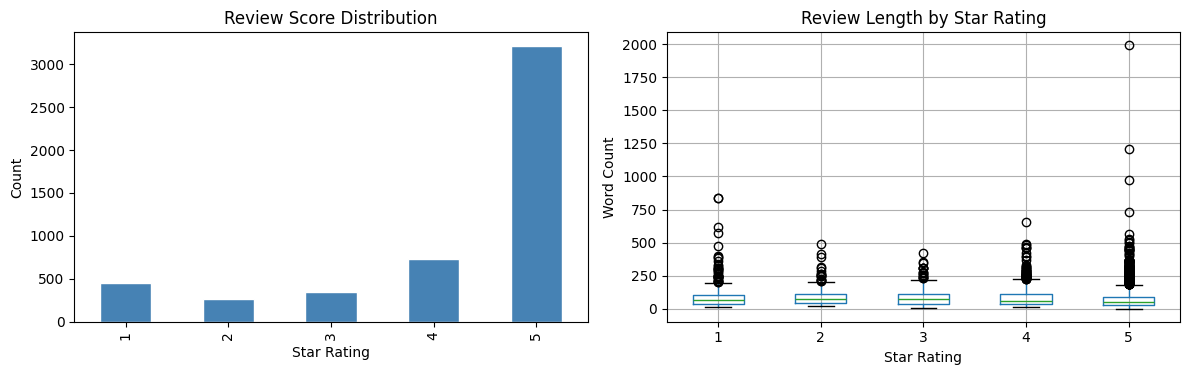

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# distribution of ratings
df['Score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Review Score Distribution')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Count')

# review length vs rating
df.boxplot(column='review_length', by='Score', ax=axes[1])
axes[1].set_title('Review Length by Star Rating')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Word Count')

plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

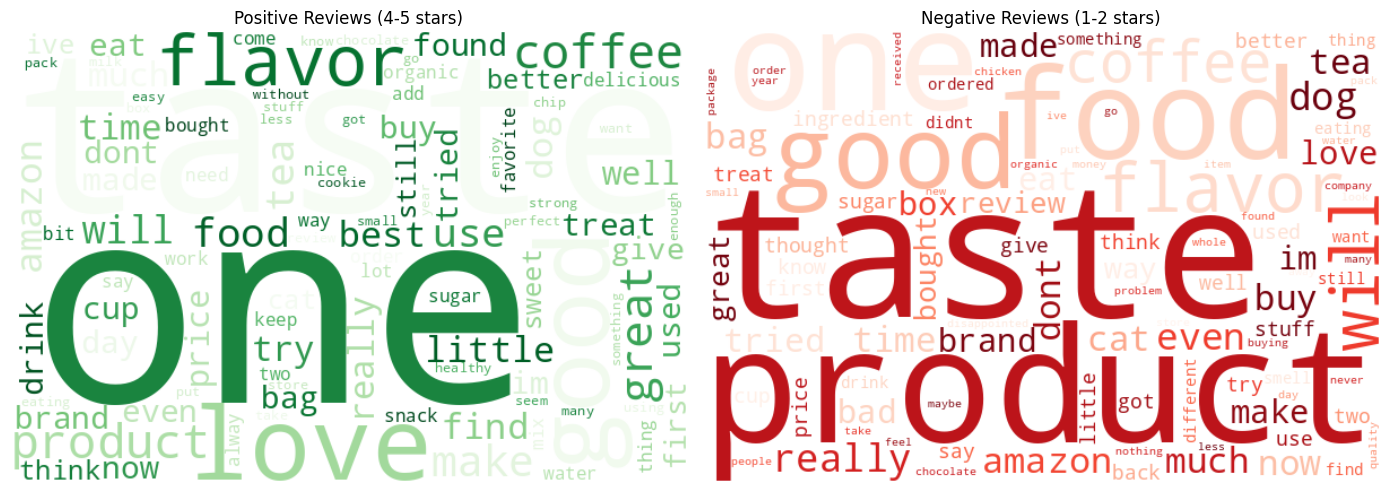

In [5]:
# combine all positive and negative reviews
positive_text = ' '.join(df[df['Score'] >= 4]['clean_text'])
negative_text = ' '.join(df[df['Score'] <= 2]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# positive word cloud
wc_pos = WordCloud(width=600, height=400,
                   background_color='white',
                   colormap='Greens',
                   max_words=100).generate(positive_text)

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Reviews (4-5 stars)')

# negative word cloud
wc_neg = WordCloud(width=600, height=400,
                   background_color='white',
                   colormap='Reds',
                   max_words=100).generate(negative_text)

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Reviews (1-2 stars)')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# initialize analyzer
analyzer = SentimentIntensityAnalyzer()

# compute sentiment score for each review
df['compound_score'] = df['Text'].apply(
    lambda x: analyzer.polarity_scores(x)['compound']
)

# classify sentiment based on score
def sentiment_label(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['compound_score'].apply(sentiment_label)

# check distribution
print(df['sentiment'].value_counts())
df[['Score', 'compound_score', 'sentiment']].head(10)

sentiment
Positive    4419
Negative     476
Neutral      105
Name: count, dtype: int64


,Score,compound_score,sentiment
0,4,0.9203,Positive
1,4,0.8346,Positive
2,5,0.9891,Positive
3,4,0.9896,Positive
4,2,0.9593,Positive
5,5,0.4588,Positive
6,5,0.9898,Positive
7,5,0.9776,Positive
8,5,0.8675,Positive
9,5,0.9350,Positive


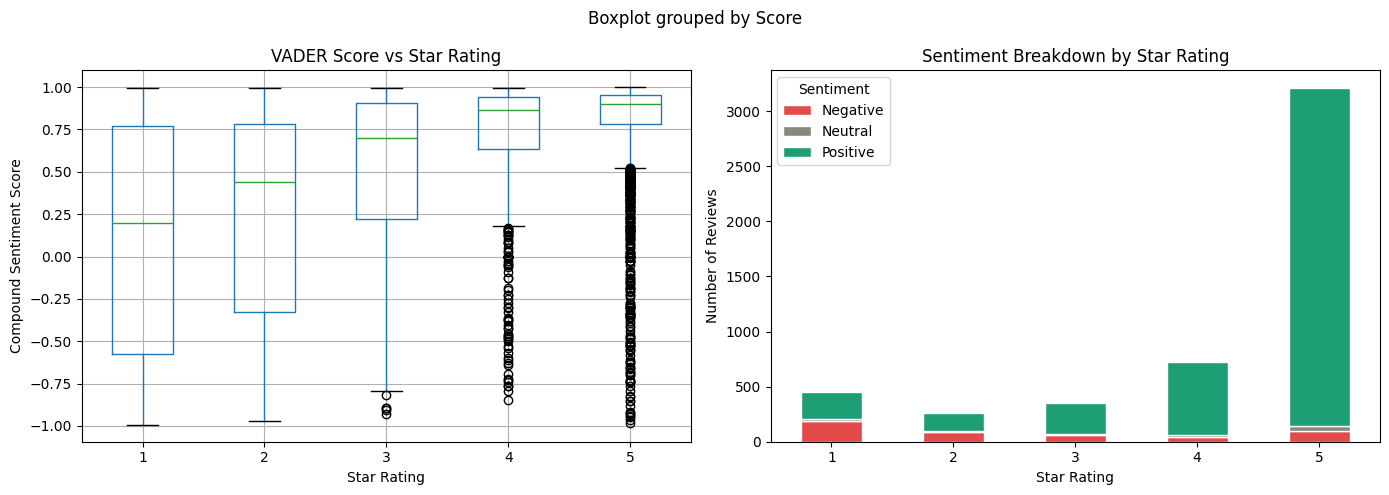

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# boxplot: sentiment score vs rating
df.boxplot(column='compound_score', by='Score', ax=axes[0])
axes[0].set_title('VADER Score vs Star Rating')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Compound Sentiment Score')

# stacked bar: sentiment distribution per rating
sentiment_counts = df.groupby(['Score', 'sentiment']).size().unstack(fill_value=0)

sentiment_counts.plot(kind='bar', stacked=True, ax=axes[1],
                      color=['#E24B4A', '#888780', '#1D9E75'],
                      edgecolor='white')

axes[1].set_title('Sentiment Breakdown by Star Rating')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Number of Reviews')
axes[1].legend(title='Sentiment')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# check how many 5-star reviews are predicted positive
print("\nAccuracy check: % positive VADER for 5-star reviews:")

accuracy = round(
    len(df[(df['Score'] == 5) & (df['sentiment'] == 'Positive')]) /
    len(df[df['Score'] == 5]) * 100, 1
)

print(accuracy, "%")


Accuracy check: % positive VADER for 5-star reviews:
95.5 %


In [9]:
# ============================================
# PROJECT: Amazon Review Sentiment Analysis
# ============================================

# WHAT THIS NOTEBOOK DOES:

# 1. Loads Amazon review dataset (Score, Text, Summary)

# 2. Cleans text data:
#    - Removes HTML tags
#    - Removes special characters
#    - Converts text to lowercase

# 3. Creates new feature:
#    - review_length → number of words in each review

# 4. Performs EDA (Exploratory Data Analysis):
#    - Distribution of star ratings
#    - Review length vs rating (boxplot)

# 5. Generates Word Clouds:
#    - Positive reviews (4–5 stars)
#    - Negative reviews (1–2 stars)

# 6. Applies Sentiment Analysis using VADER:
#    - Calculates compound sentiment score
#    - Classifies into Positive / Negative / Neutral

# 7. Compares sentiment with actual ratings:
#    - Boxplot: sentiment score vs rating
#    - Stacked bar: sentiment distribution per rating

# 8. Performs basic accuracy check:
#    - % of 5-star reviews predicted as Positive

# OUTPUT:
# - EDA plots (eda_plots.png)
# - Word clouds (wordclouds.png)
# - Sentiment analysis plots (sentiment_analysis.png)

# ============================================